In [ ]:
# === MASTER CELL ===
# Lädt alle Daten und Bibliotheken
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("/content/q_fit_results.csv")

print("Dateien in /content:")
print(os.listdir("/content"))

print("\nErste Zeilen:")
print(df.head())

print("\nSpalten:")
print(df.columns)

In [ ]:
def get_type(name):
    name = str(name).upper()

    if name.startswith("NGC"):
        return "NGC"
    elif name.startswith("UGC") or name.startswith("UGCA"):
        return "UGC"
    elif name.startswith("DDO") or name.startswith("D"):
        return "Dwarf"
    elif name.startswith("IC"):
        return "IC"
    elif name.startswith("ESO"):
        return "ESO"
    elif name.startswith("F"):
        return "LSB"
    else:
        return "Other"

df["type"] = df["filename"].apply(get_type)

print(df[["filename", "type", "q"]].head())

              filename type         q
0   UGCA444_rotmod.dat  UGC  3.000000
1   UGCA442_rotmod.dat  UGC  0.485413
2   UGCA281_rotmod.dat  UGC  0.581791
3  UGC12732_rotmod.dat  UGC  3.000000
4  UGC12632_rotmod.dat  UGC  0.679549


In [44]:
peak = (df["q"] < 1.2).mean()
diffuse = (df["q"] > 2.5).mean()
transition = ((df["q"] >= 1.2) & (df["q"] < 2.5)).mean()

print("Peak:", peak)
print("Diffuse:", diffuse)
print("Transition:", transition)

Peak: 0.6219512195121951
Diffuse: 0.25609756097560976
Transition: 0.12195121951219512


In [45]:
type_means = df.groupby("type")["q"].mean().sort_values()
print(type_means)

type_means.to_csv("/content/q_mean_by_type.csv")

type
Other    0.362564
Dwarf    0.508745
LSB      0.957716
ESO      1.046774
UGC      1.257162
NGC      1.604654
IC       3.000000
Name: q, dtype: float64


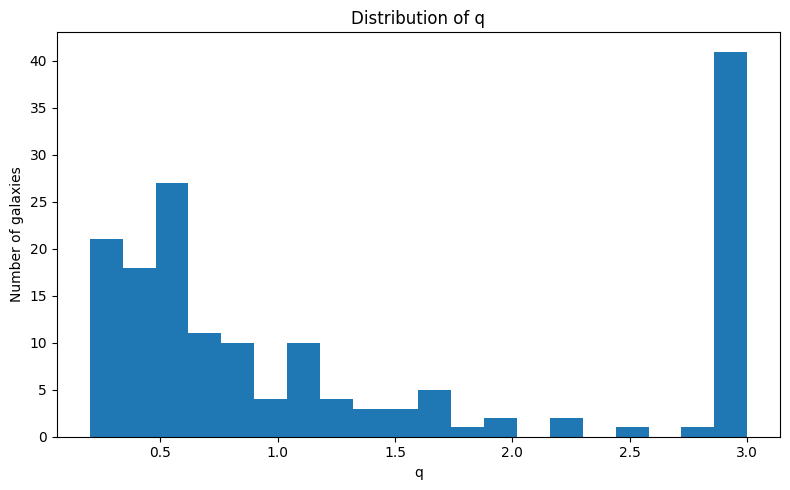

In [46]:
plt.figure(figsize=(8,5))
plt.hist(df["q"], bins=20)

plt.xlabel("q")
plt.ylabel("Number of galaxies")
plt.title("Distribution of q")
plt.tight_layout()

plt.savefig("/content/q_histogram.png", dpi=300)
plt.show()

<Figure size 900x500 with 0 Axes>

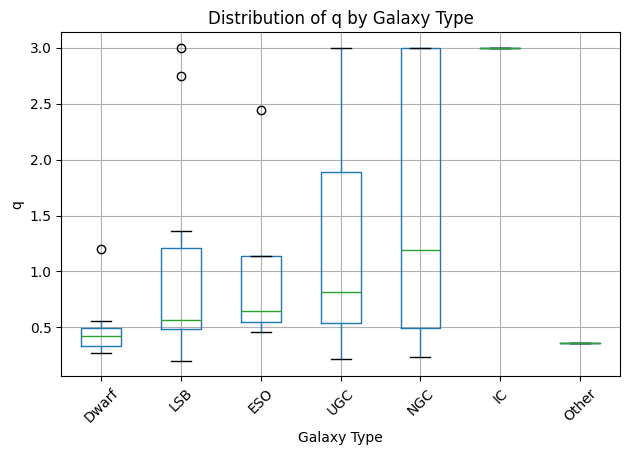

In [47]:
order = ["Dwarf", "LSB", "ESO", "UGC", "NGC", "IC", "Other"]
df["type"] = pd.Categorical(df["type"], categories=order, ordered=True)

plt.figure(figsize=(9,5))
df.boxplot(column="q", by="type")

plt.title("Distribution of q by Galaxy Type")
plt.suptitle("")
plt.xlabel("Galaxy Type")
plt.ylabel("q")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("/content/q_by_type.png", dpi=300)
plt.show()

In [48]:
summary = pd.DataFrame({
    "quantity": ["Peak fraction", "Diffuse fraction", "Transition fraction"],
    "value": [peak, diffuse, transition]
})

summary.to_csv("/content/regime_summary.csv", index=False)
print(summary)

              quantity     value
0        Peak fraction  0.621951
1     Diffuse fraction  0.256098
2  Transition fraction  0.121951
